# Hello, KAN!

### Kolmogorov-Arnold representation theorem

Kolmogorov-Arnold representation theorem states that if $f$ is a multivariate continuous function
on a bounded domain, then it can be written as a finite composition of continuous functions of a
single variable and the binary operation of addition. More specifically, for a smooth $f : [0,1]^n \to \mathbb{R}$,


$$f(x) = f(x_1,...,x_n)=\sum_{q=1}^{2n+1}\Phi_q(\sum_{p=1}^n \phi_{q,p}(x_p))$$

where $\phi_{q,p}:[0,1]\to\mathbb{R}$ and $\Phi_q:\mathbb{R}\to\mathbb{R}$. In a sense, they showed that the only true multivariate function is addition, since every other function can be written using univariate functions and sum. However, this 2-Layer width-$(2n+1)$ Kolmogorov-Arnold representation may not be smooth due to its limited expressive power. We augment its expressive power by generalizing it to arbitrary depths and widths.

### Kolmogorov-Arnold Network (KAN)

The Kolmogorov-Arnold representation can be written in matrix form

$$f(x)={\bf \Phi}_{\rm out}\circ{\bf \Phi}_{\rm in}\circ {\bf x}$$

where 

$${\bf \Phi}_{\rm in}= \begin{pmatrix} \phi_{1,1}(\cdot) & \cdots & \phi_{1,n}(\cdot) \\ \vdots & & \vdots \\ \phi_{2n+1,1}(\cdot) & \cdots & \phi_{2n+1,n}(\cdot) \end{pmatrix},\quad {\bf \Phi}_{\rm out}=\begin{pmatrix} \Phi_1(\cdot) & \cdots & \Phi_{2n+1}(\cdot)\end{pmatrix}$$

We notice that both ${\bf \Phi}_{\rm in}$ and ${\bf \Phi}_{\rm out}$ are special cases of the following function matrix ${\bf \Phi}$ (with $n_{\rm in}$ inputs, and $n_{\rm out}$ outputs), we call a Kolmogorov-Arnold layer:

$${\bf \Phi}= \begin{pmatrix} \phi_{1,1}(\cdot) & \cdots & \phi_{1,n_{\rm in}}(\cdot) \\ \vdots & & \vdots \\ \phi_{n_{\rm out},1}(\cdot) & \cdots & \phi_{n_{\rm out},n_{\rm in}}(\cdot) \end{pmatrix}$$

${\bf \Phi}_{\rm in}$ corresponds to $n_{\rm in}=n, n_{\rm out}=2n+1$, and ${\bf \Phi}_{\rm out}$ corresponds to $n_{\rm in}=2n+1, n_{\rm out}=1$.

After defining the layer, we can construct a Kolmogorov-Arnold network simply by stacking layers! Let's say we have $L$ layers, with the $l^{\rm th}$ layer ${\bf \Phi}_l$ have shape $(n_{l+1}, n_{l})$. Then the whole network is

$${\rm KAN}({\bf x})={\bf \Phi}_{L-1}\circ\cdots \circ{\bf \Phi}_1\circ{\bf \Phi}_0\circ {\bf x}$$

In constrast, a Multi-Layer Perceptron is interleaved by linear layers ${\bf W}_l$ and nonlinearities $\sigma$:

$${\rm MLP}({\bf x})={\bf W}_{L-1}\circ\sigma\circ\cdots\circ {\bf W}_1\circ\sigma\circ {\bf W}_0\circ {\bf x}$$

A KAN can be easily visualized. (1) A KAN is simply stack of KAN layers. (2) Each KAN layer can be visualized as a fully-connected layer, with a 1D function placed on each edge. Let's see an example below.

### Get started with KANs

Initialize KAN

In [1]:
from kan import *
import torch
torch.set_default_dtype(torch.float64)
device = torch.device('cpu')
print(device)

model = KAN(width=[100, 1 ,1], grid=3, k=3, seed=42, device=device)

cpu
checkpoint directory created: ./model
saving model version 0.0


Create dataset

In [2]:
from kan.utils import create_dataset
# create dataset f(x,y) = exp(sin(pi*x)+y^2)
f = lambda x: torch.exp((1.0 / 100) * torch.sum(torch.sin(torch.pi * x / 2) ** 2, dim=1, keepdim=True))
dataset = create_dataset(f, n_var=100, device=device, train_num=10000, test_num=1000)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([10000, 100]), torch.Size([10000, 1]))

Plot KAN at initialization

In [3]:
# plot KAN at initialization
model(dataset['train_input'])

tensor([[0.0810],
        [0.0547],
        [0.0642],
        ...,
        [0.0737],
        [0.0330],
        [0.0092]], grad_fn=<AddBackward0>)

Train KAN with sparsity regularization

In [4]:
# # train the model
# model.fit(dataset, opt="LBFGS", steps=200);

In [5]:
grids = [3, 5, 10, 20, 50, 100]
losses = []

for g in grids:
    model = model.refine(g)
    
    result = model.fit(dataset, opt="LBFGS", steps=200, update_grid=False)
    losses.append(result['test_loss'][-1])
    print(result['test_loss'][-1])

saving model version 0.1


| train_loss: 2.03e-03 | test_loss: 2.23e-03 | reg: 7.07e+00 | : 100%|█| 200/200 [20:13<00:00,  6.07


saving model version 0.2
0.0022312375313719227
saving model version 0.3


| train_loss: 2.08e-04 | test_loss: 2.17e-04 | reg: 5.93e+00 | : 100%|█| 200/200 [21:03<00:00,  6.32


saving model version 0.4
0.00021669094771634186
saving model version 0.5


...

saving model version 0.8
4.6597799389026966e-05
saving model version 0.9


| train_loss: 4.43e-05 | test_loss: 9.25e-05 | reg: 3.74e+00 | : 100%|█| 200/200 [1:27:41<00:00, 26.


saving model version 0.10
9.254658870929726e-05
saving model version 0.11


| train_loss: 2.64e-04 | test_loss: 1.89e-03 | reg: 3.38e+00 | : 100%|█| 200/200 [2:30:09<00:00, 45.

saving model version 0.12
0.0018945209312157413


[  707   909  1414  2424  5454 10504]
[array(0.00223124), array(0.00021669), array(2.61409976e-05), array(4.65977994e-05), array(9.25465887e-05), array(0.00189452)]


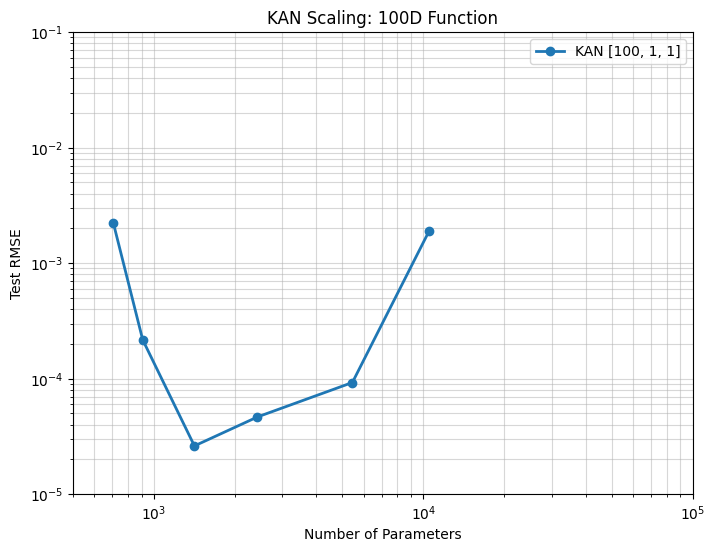

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))
params_counts = 101 * (np.array(grids)+4)
print(params_counts)
print(losses)
plt.plot(params_counts, losses, marker='o', lw=2, label='KAN [100, 1, 1]')


plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-5, 1e-1)
plt.xlim(5e2, 1e5)
plt.xlabel('Number of Parameters')
plt.ylabel('Test RMSE')
plt.title('KAN Scaling: 100D Function')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()